# Waterpark in a notebook: ERA5, July 2021

Near-surface air temperature for July 2021 from ERA5 on Waterpark's HEALPix grid, found through Freva and read straight from S3.

The map below is the output of the cell, saved with the notebook so you can see it at once. Run the cell (Shift+Enter) to compute it again in your browser: it asks Freva for the store, opens it lazily and reads just that one month.

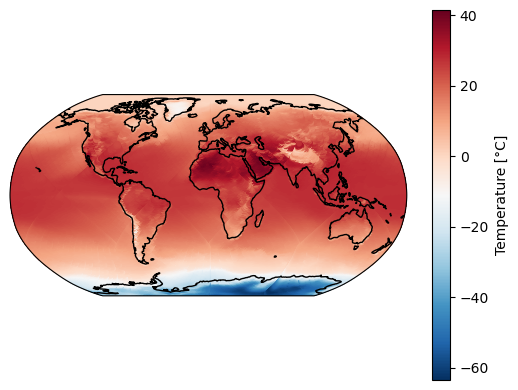

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from freva_client import databrowser

# Ask Freva what exists. This is metadata only; nothing is downloaded yet.
db = databrowser(
    project="waterpark",
    product="reanalysis-healpix",
    model="ifs-cy41r2",
    experiment="era5",
    time_frequency="mon",
    host="https://freva.dkrz.de",
)

url = list(db)[0]

# Open lazily, then read just one month.
ds = xr.open_zarr(url, chunks={})
tas = ds["tas"].sel(time="2021-07").compute()

ax = plt.axes(projection=ccrs.Robinson())
sc = ax.scatter(
    tas.longitude, tas.latitude,
    c=tas - 273.15,
    s=8,
    cmap="RdBu_r",
    transform=ccrs.PlateCarree(),
)

ax.coastlines()
ax.set_global()
plt.colorbar(sc, label="Temperature [°C]")
plt.show()